#### Analysis of features for SAFEX commodities - CTA strategy
Purpose of this notebook: Run IC matrix across features, check feature correlation and parameter sweeps

Feature functions live in `src/features.py`, screening and plots in `src/utilities.py`,
the model in `src/model.py`.

In [26]:
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2

# Put the project root and src/ on the path so the modules below import
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import features
import utilities
import model

from theme import set_theme
set_theme()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'rc_params': {'figure.facecolor': '#282c34',
  'axes.facecolor': '#282c34',
  'savefig.facecolor': '#282c34',
  'axes.edgecolor': '#3e4451',
  'axes.labelcolor': '#abb2bf',
  'text.color': '#abb2bf',
  'xtick.color': '#abb2bf',
  'ytick.color': '#abb2bf',
  'axes.grid': True,
  'grid.color': '#3e4451',
  'grid.linewidth': 0.6,
  'grid.linestyle': '-',
  'font.size': 9},
 'palette': ['#61afef', '#98c379', '#e5c07b', '#d19a66', '#c678dd', '#e06c75']}

### 1. Load

In [27]:
# Set path
path = ROOT / "data" / "processed" / "df_combined.parquet"

# Read df
df = pd.read_parquet(path)
df.columns

Index(['expiry', 'trade_date', 'contract', 'expiry_month',
       'safex_zar_per_tonne', 'safex_volume', 'safex_open_interest',
       'source_file', 'raw_symbol', 'cbot_usd_per_tonne', 'cbot_volume',
       'staleness_hours', 'usdzar', 'safex_usd_per_tonne', 'ym_corn_arb',
       'log_safex_usd', 'log_safex_zar', 'log_cbot', 'ym_corn_arb_log',
       'arb_z', 'own_z', 'cbot_z', 'vol', 'yw_spread', 'yw_z', 'yw_change',
       'wm_zar_per_tonne', 'wm_usd_per_tonne', 'wm_corn_arb', 'wm_arb_z',
       'fwd_zar_1', 'fwd_usd_1', 'fwd_arb_1', 'fwd_zar_3', 'fwd_usd_3',
       'fwd_arb_3', 'fwd_zar_5', 'fwd_usd_5', 'fwd_arb_5', 'fwd_zar_10',
       'fwd_usd_10', 'fwd_arb_10', 'fwd_zar_21', 'fwd_usd_21', 'fwd_arb_21'],
      dtype='str')

### 2. Feature matrix

Log returns are taken within expiry so no return spans a roll, then summed back up
into a continuous log price (`clog_`). Every feature below is built on that.

In [28]:
# Build dataframe
feat = df.copy()
to_keep = ["expiry", "trade_date", "contract", "expiry_month", "safex_zar_per_tonne", "safex_volume",
           "safex_open_interest", "cbot_usd_per_tonne", "usdzar", "safex_usd_per_tonne", "ym_corn_arb",
           "yw_spread", "yw_z", "wm_zar_per_tonne", "wm_usd_per_tonne"]
feat = feat[to_keep]

contract_cols = ["safex_zar_per_tonne", "safex_usd_per_tonne", "cbot_usd_per_tonne",
                 "wm_zar_per_tonne", "wm_usd_per_tonne"]
spot_cols = ["usdzar"]
spread_cols = ["ym_corn_arb", "yw_spread"]

# Build log returns and pct returns on columns
feat = features.build_log_returns(feat, contract_cols, spot_cols, spread_cols)

feat.filter(like="clog_").head()

,clog_safex_zar_per_tonne,clog_safex_usd_per_tonne,clog_cbot_usd_per_tonne,clog_wm_zar_per_tonne,clog_wm_usd_per_tonne,clog_usdzar
dt,,,,,,
2010-06-07,7.022868,4.969809,4.889356,6.982863,4.929804,2.053059
2010-06-08,6.997596,4.943472,4.887874,6.949856,4.895733,2.054124
2010-06-09,6.993015,4.946394,4.888615,6.948897,4.902276,2.046621
2010-06-10,7.006695,4.959712,4.889356,6.964136,4.917153,2.046983
2010-06-11,7.015712,4.973493,4.906978,6.973543,4.931323,2.042220


### 3. Build the features

#### 3.1 Build OLS rolling beta between Safex and Cbot
Looking at the long run mean of the beta, it has large variability.
The mean centers around 0.5, meaning for every 1 move in cbot, ym moves roughly half.

count    3827.000
mean        0.526
std         0.138
min         0.120
25%         0.445
50%         0.542
75%         0.611
max         0.867
Name: hedge_beta_v2, dtype: float64


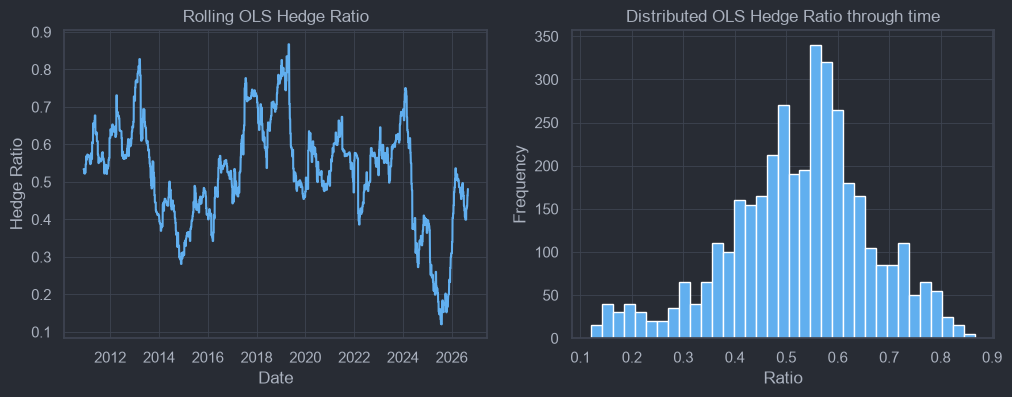

In [29]:
# v2 beta on returns, spread accumulated from hedged returns
feat["hedge_beta_v2"], feat["c_arb_hedged_v2"] = features.hedged_spread(feat, base_col="clog_cbot_usd_per_tonne", quote_col="clog_safex_usd_per_tonne"
)
print(feat["hedge_beta_v2"].describe().round(3))
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(feat["hedge_beta_v2"])
axs[0].set(xlabel="Date", ylabel="Hedge Ratio", title="Rolling OLS Hedge Ratio")
axs[1].hist(feat["hedge_beta_v2"], bins=35)
axs[1].set(xlabel="Ratio", ylabel="Frequency", title="Distributed OLS Hedge Ratio through time")
plt.show()

In [149]:
# Determine variables
PRICE = "c_arb_hedged_v2"   # continuous arb
MA_WINDOWS = [20, 200]
VOL_WINDOWS = [10, 20, 60, 120]
HORIZONS = [20]
CROSS_PAIRS = [(20, 50), (50, 100)]
ABOVE_WINDOWS = [10, 20]
SPREAD_WINDOWS = [10,15, 20, 60]

# Build features
# Build features based on the type of signal you are trying to forecast - Mean Reversion, Momentum, Economic, Seasonality

# Momentum Features
feat = features.moving_avg_feat(feat, PRICE, windows=MA_WINDOWS, z_window=120)
feat = features.ma_momentum_feat(feat, PRICE, cross_pairs=CROSS_PAIRS, above_windows=ABOVE_WINDOWS)
# Economic Features
feat = features.seasonality_feat(feat)
feat = features.days_to_harvest_feat(feat)
# Regime Features
feat = features.vol_regime_feat(feat, PRICE, windows=VOL_WINDOWS)
feat = features.volume_feat(feat, "safex_volume")

# Raw (non-normalised) forward targets.
for horizon in HORIZONS:
    feat[f"target_raw_{horizon}_d"] = feat[PRICE].shift(-horizon) - feat[PRICE]


# Beta Features
# Spread-state: is the spread in a reverting regime right now?
for window in SPREAD_WINDOWS:
    feat[f"ou_half_life_{window}"] = features.ou_half_life(feat[PRICE], window)
    feat[f"var_ratio_{window}"] = features.variance_ratio(feat[PRICE], window)

# Relationship stability -- the quantified form of the non-cointegration finding.
# Fast beta (input to beta_gap only) and slow beta (the series we model).
feat["hedge_beta_fast"], _ = features.hedged_spread(
    feat, "clog_cbot_usd_per_tonne", "clog_safex_usd_per_tonne", window=120
)
feat["hedge_beta_v2"], feat["c_arb_hedged_v2"] = features.hedged_spread(
    feat, "clog_cbot_usd_per_tonne", "clog_safex_usd_per_tonne", window=500
)
feat["beta_sd_60"] = feat["hedge_beta_v2"].rolling(60).std()
feat["beta_gap"] = feat["hedge_beta_fast"] - feat["hedge_beta_v2"]

# Cross-leg: information from the legs, not the spread's own path.
for window in SPREAD_WINDOWS:
    feat[f"xleg_corr_{window}"] = features.cross_leg_correlation(
        feat, "clog_safex_usd_per_tonne", "clog_cbot_usd_per_tonne", window
    )
    feat[f"rel_vol_{window}"] = features.relative_volatility(
        feat, "clog_safex_usd_per_tonne", "clog_cbot_usd_per_tonne", window
    )

# Target
feat = features.forward_horizons(feat, PRICE, horizons=HORIZONS, vol_window=20)
raw_target_cols = [f"target_raw_{h}_d" for h in HORIZONS]
target_cols = [f"target_{h}_d" for h in HORIZONS]

# Add new features.

BLOCKS = {
    "momentum":     [f"{PRICE}_macd", f"{PRICE}_macross_20_50", f"{PRICE}_above_ma_20"],
    "reversion":    [f"{PRICE}_ma_dist_z_20", f"{PRICE}_ma_dist_z_200"],
    "spread_state": ["ou_half_life_20", "ou_half_life_60",
                     "var_ratio_20", "var_ratio_60",
                     "beta_sd_60", "beta_gap"],
    "cross_leg":    ["xleg_corr_20", "xleg_corr_60",
                     "rel_vol_20", "rel_vol_60", "yw_z"],
    "state":        ["vol_regime", "volume_trend", "days_to_harvest", "season_sin", "season_cos"],
}

### 4. IC screen

Selection runs on the train slice only. If the screen picks winners using all the
data, anything tested later is scoring the selection rather than the signal.

In [150]:
# Block-wise IC screen.
#
# Each block faces a Bonferroni bar

from scipy.stats import norm

TRAIN_END = "2020-12-31"
train = feat.loc[:TRAIN_END]

print(f"train {train.index.min():%Y-%m-%d} to {train.index.max():%Y-%m-%d}  n={len(train)}")
print(f"holdout {len(feat) - len(train)} rows\n")


def screen_block(train_df, block_features, target_cols, ic_floor=0.02):
    """IC screen for one block. Returns the per-feature best horizon and the
    block's own Bonferroni bar."""
    rows = []
    for target in target_cols:
        horizon = int(target.split("_")[1])
        ic = utilities.ic_rank_spearman(train_df, block_features, target)
        t = utilities.nw_t_stat(train_df, block_features, target, lags=horizon)
        for feature in block_features:
            rows.append({
                "block": None,                      # filled by the caller
                "feature": feature,
                "target": target,
                "ic": ic.loc[feature, "ic"],
                "t_nw": t.loc[feature, "t_nw"],
                "p_nw": t.loc[feature, "p_nw"],
                "n": ic.loc[feature, "n"],
            })

    block_screen = pd.DataFrame(rows).astype(
        {"ic": float, "t_nw": float, "p_nw": float, "n": int}
    )

    # Best horizon per feature, ranked by absolute t.
    best = block_screen.loc[
        block_screen.groupby("feature")["t_nw"].apply(lambda s: s.abs().idxmax())
    ].sort_values("t_nw", key=abs, ascending=False)

    bar = abs(norm.ppf(0.025 / len(block_screen)))
    survivors = best[(best["t_nw"].abs() >= bar) & (best["ic"].abs() >= ic_floor)]

    return {
        "screen": block_screen,
        "best": best,
        "survivors": survivors,
        "n_tests": len(block_screen),
        "bar": bar,
    }


results = {}
for block_name, block_features in BLOCKS.items():
    # Only screen what actually made it into the frame.
    available = [f for f in block_features if f in train.columns]
    missing = set(block_features) - set(available)
    if missing:
        print(f"  ! {block_name}: missing {sorted(missing)}")
    if not available:
        continue

    r = screen_block(train, available, target_cols)
    r["screen"]["block"] = block_name
    r["best"] = r["best"].assign(block=block_name)
    r["survivors"] = r["survivors"].assign(block=block_name)
    results[block_name] = r

    print(f"{block_name:<14} {r['n_tests']:>3} tests | bar t>={r['bar']:.2f} | "
          f"survivors: {r['survivors']['feature'].tolist()}")

# Pooled frame, kept for the noise-floor ratio table and horizon choice.
screen = pd.concat([r["screen"] for r in results.values()], ignore_index=True)
best = pd.concat([r["best"] for r in results.values()]).sort_values(
    "t_nw", key=abs, ascending=False
)

print(f"\ntotal tests across blocks: {len(screen)}")
best[["block", "feature", "target", "ic", "t_nw", "p_nw", "n"]].round(4)

train 2010-06-07 to 2020-12-31  n=2572
holdout 1375 rows

momentum         3 tests | bar t>=2.39 | survivors: []
reversion        2 tests | bar t>=2.24 | survivors: []
spread_state     6 tests | bar t>=2.64 | survivors: []
cross_leg        5 tests | bar t>=2.58 | survivors: ['yw_z']
state            5 tests | bar t>=2.58 | survivors: []

total tests across blocks: 21


,block,feature,target,ic,t_nw,p_nw,n
4,cross_leg,yw_z,target_20_d,0.2377,3.3133,0.0009,2013
3,cross_leg,rel_vol_60,target_20_d,-0.1848,-2.3985,0.0165,2051
3,state,season_sin,target_20_d,-0.1410,-1.9341,0.0531,2051
1,cross_leg,xleg_corr_60,target_20_d,0.1230,1.7870,0.0739,2051
2,state,days_to_harvest,target_20_d,0.1135,1.6313,0.1028,2051
2,spread_state,var_ratio_20,target_20_d,-0.1013,-1.6205,0.1051,2047
1,momentum,c_arb_hedged_v2_macross_20_50,target_20_d,0.1337,1.6152,0.1063,1771
3,spread_state,var_ratio_60,target_20_d,-0.1199,-1.5969,0.1103,2007
4,state,season_cos,target_20_d,-0.1195,-1.4913,0.1359,2051
0,momentum,c_arb_hedged_v2_macd,target_20_d,0.1179,1.4316,0.1522,1820


### 5. IC decay

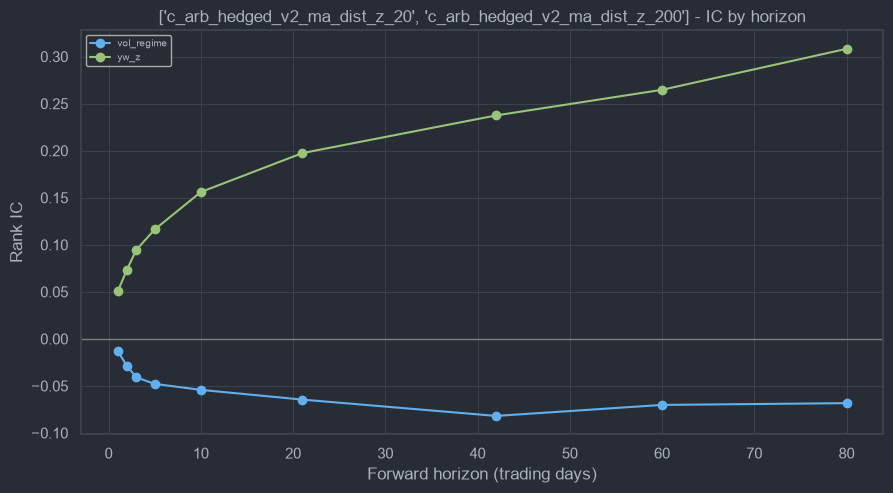

,1,2,3,5,10,21,42,60,80
vol_regime,-0.0132,-0.0288,-0.0410,-0.0478,-0.0542,-0.0645,-0.0819,-0.0702,-0.0683
yw_z,0.0508,0.0737,0.0945,0.1163,0.1560,0.1974,0.2374,0.2647,0.3082


In [157]:
# Plot IC decay for a feature
decay_horizons = [1, 2, 3, 5, 10, 21, 42, 60, 80]
decay_feat = features.forward_horizons(feat.copy(), PRICE, horizons=decay_horizons, vol_window=20)

ma_features = [f"{PRICE}_ma_dist_z_{w}" for w in MA_WINDOWS]
feats = feat[["vol_regime", "yw_z"]]
ic_table = utilities.ic_decay(decay_feat, features=feats, horizons=decay_horizons)

utilities.plot_ic_decay(ic_table, title=f"{ma_features} - IC by horizon")
ic_table.round(4)

### 6. Feature correlation

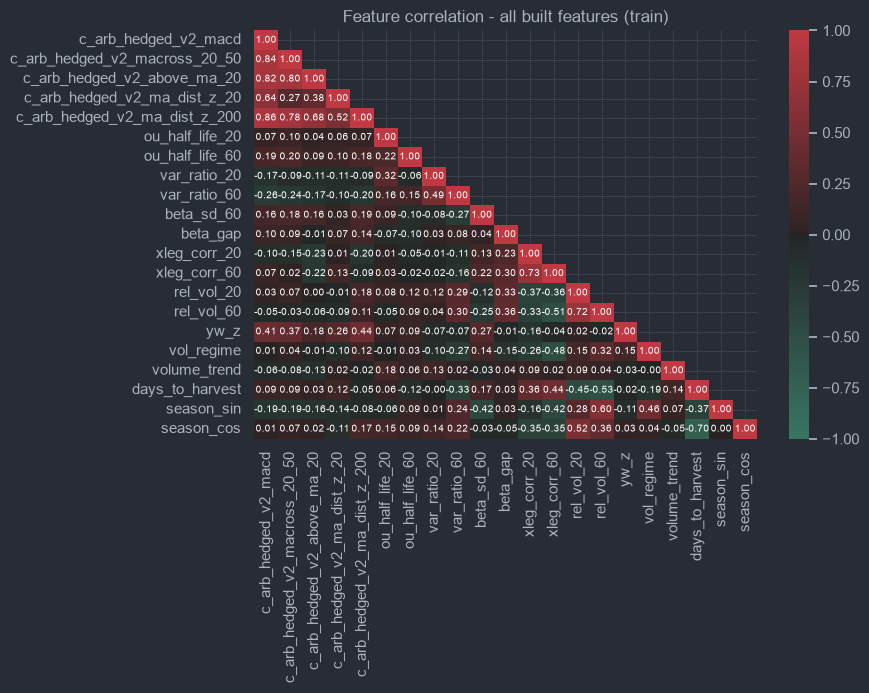

In [187]:
# identify multi-collinearity

# Everything built in section 3 that actually made it into the frame,
# but kept in block order so related features sit next to each other.
created = list(dict.fromkeys(f for block in BLOCKS.values() for f in block if f in train.columns))

corr = utilities.plot_feature_correlation(train, created, title="Feature correlation - all built features (train)")


### 7. Select

Bonferroni corrects for how many tests were run: more features means a higher bar
for all of them.

In [160]:
from scipy.stats import norm
# Select features based on IC, t-stat and T-Bon
IC_FLOOR = 0.02
T_NOMINAL = 2.0
T_BONFERRONI = abs(norm.ppf(0.025 / len(screen)))

survivors = best[(best["t_nw"].abs() >= T_BONFERRONI) & (best["ic"].abs() >= IC_FLOOR)]
nominal = best[(best["t_nw"].abs() >= T_NOMINAL) & (best["ic"].abs() >= IC_FLOOR)]

print(f"{len(screen)} tests -> bonferroni bar t >= {T_BONFERRONI:.2f}")
print(f"survive bonferroni: {len(survivors)}")
print(f"survive nominal:    {len(nominal)}  {nominal['feature'].tolist()}")
nominal.round(4)

21 tests -> bonferroni bar t >= 3.04
survive bonferroni: 1
survive nominal:    2  ['yw_z', 'rel_vol_60']


,block,feature,target,ic,t_nw,p_nw,n
4,cross_leg,yw_z,target_20_d,0.2377,3.3133,0.0009,2013
3,cross_leg,rel_vol_60,target_20_d,-0.1848,-2.3985,0.0165,2051


In [161]:
# Signal breadth by horizon: how many features carry weight at each horizon,
# rather than which single cell is brightest.
by_horizon = screen.groupby("target").agg(
    n_above_2=("t_nw", lambda s: (s.abs() >= 2.0).sum()),
    mean_abs_ic=("ic", lambda s: s.abs().mean()),
    max_abs_t=("t_nw", lambda s: s.abs().max()),
)
print(by_horizon.round(3))

             n_above_2  mean_abs_ic  max_abs_t
target                                        
target_20_d          2        0.096      3.313


In [162]:
# mean |IC| rises with horizon partly because the effective sample shrinks:
# overlapping targets mean n_eff is roughly n/horizon, and |IC| under pure
# noise scales as 1/sqrt(n_eff). Normalise before comparing across horizons.
rows = []
for target, group in screen.groupby("target"):
    horizon = int(target.split("_")[1])
    n_eff = group["n"].median() / horizon
    noise_floor = np.sqrt(2 / np.pi) / np.sqrt(n_eff)   # E|IC| if true IC is 0
    rows.append({
        "horizon": horizon,
        "n_eff": round(n_eff),
        "mean_abs_ic": group["ic"].abs().mean(),
        "noise_floor": noise_floor,
        "ratio": group["ic"].abs().mean() / noise_floor,
        "n_above_2": (group["t_nw"].abs() >= 2).sum(),
    })
pd.DataFrame(rows).sort_values("horizon").round(3)

,horizon,n_eff,mean_abs_ic,noise_floor,ratio,n_above_2
0,20,101,0.096,0.08,1.207,2


### 8. Multicollinearity prune

In [163]:
CORR_BAR = 0.7

candidates = nominal.sort_values("t_nw", key=abs, ascending=False)["feature"].tolist()
cand_corr = utilities.feature_correlation(train, candidates).abs()

# Walk the list strongest first, keep a feature only if it is not a near-duplicate
# of one already kept.
kept = []
for candidate in candidates:
    is_duplicate = False
    for already_kept in kept:
        if cand_corr.loc[candidate, already_kept] >= CORR_BAR:
            is_duplicate = True
            print(f"dropped {candidate} (corr {cand_corr.loc[candidate, already_kept]:.2f} with {already_kept})")
    if not is_duplicate:
        kept.append(candidate)

print()
print(f"kept {len(kept)} of {len(candidates)}")
kept


kept 2 of 2


['yw_z', 'rel_vol_60']

### 9. Model

`grid=None` uses the default hyperparameters. Pass a grid to switch the inner
validation loop on - it picks parameters inside each fold's training data only.

In [164]:
# Build target and horizon - These need to match to ensure no leakage
TARGET = "target_20_d"
HORIZON = int(TARGET.split("_")[1])
#ONE_FEAT = ["ou_half_life_60"]

data = feat[kept + [TARGET]].dropna()
X = data[kept]
y = data[TARGET]

# Row number where the holdout starts. Folds testing before this are dropped,
# because the screen already saw that period when it chose the features.
holdout_start = data.index.searchsorted(pd.Timestamp(TRAIN_END))
print(f"holdout starts at row {holdout_start} of {len(data)}")

grid = model.param_grid({"max_depth": [2, 10], "learning_rate": [0.01, 0.5]})

# Build model
result = model.run_walk_forward(X, y, n_splits=5, embargo=HORIZON, kind="regressor", grid=grid,
                                min_test_start=holdout_start)

print(result["summary"])
result["folds"].round(4)

holdout starts at row 2012 of 3368
{'mean_oos_ic': 0.2393032417734856, 'folds_positive': 3, 'n_folds': 4, 'ic_std': 0.3114432388501743}


,fold,train_end,test_start,test_end,n_train,n_test,oos_ic,params,feat_rank,importance
0,0,2020-12-17,2021-01-20,2022-06-07,2004,336,-0.0821,"{'max_depth': 2, 'learning_rate': 0.01}","[yw_z, rel_vol_60]","[0.4833573, 0.5166427]"
1,1,2022-05-09,2022-06-08,2023-10-26,2340,336,0.4873,"{'max_depth': 2, 'learning_rate': 0.01}","[yw_z, rel_vol_60]","[0.5364456, 0.46355438]"
2,2,2023-09-28,2023-10-27,2025-03-18,2676,336,0.5245,"{'max_depth': 2, 'learning_rate': 0.01}","[yw_z, rel_vol_60]","[0.46635354, 0.53364646]"
3,3,2025-02-18,2025-03-19,2026-08-03,3012,336,0.0275,"{'max_depth': 2, 'learning_rate': 0.01}","[yw_z, rel_vol_60]","[0.45169365, 0.5483064]"


### 10. Performance

In [165]:
# Performance metrics
forward_return = (feat[PRICE].shift(-HORIZON) - feat[PRICE])

oos = result["predictions"].rename("pred").to_frame()
oos["fwd_raw"] = forward_return.reindex(oos.index)
oos = oos.dropna()

# The arb target is in USD/tonne, so divide by the underlying price to turn each
# trade into a percentage. That is what makes these stats comparable to any
# other product. For a log-return target, drop notional and pass log_returns=True.
notional = feat["safex_usd_per_tonne"].reindex(oos.index)

# Pass the full overlapping sample - horizon does the thinning, and averages
# over every starting offset so the answer is not an accident of where we began.
stats = model.performance_stats(oos["pred"], oos["fwd_raw"], 252 / HORIZON, notional=notional, horizon=HORIZON)

pd.Series(stats).round(4)

n                    67.0000
win_rate              0.5371
ev_pct                0.0000
median_pct            0.0000
avg_win_pct           0.0002
avg_loss_pct         -0.0001
total_return_pct      0.0026
annual_return_pct     0.0005
max_draw_down_pct    -0.0012
sharpe                0.6684
sortino               1.2575
calmar                0.4510
t_stat                1.5448
n_offsets            20.0000
sharpe_min            0.3335
sharpe_max            1.1727
dtype: float64

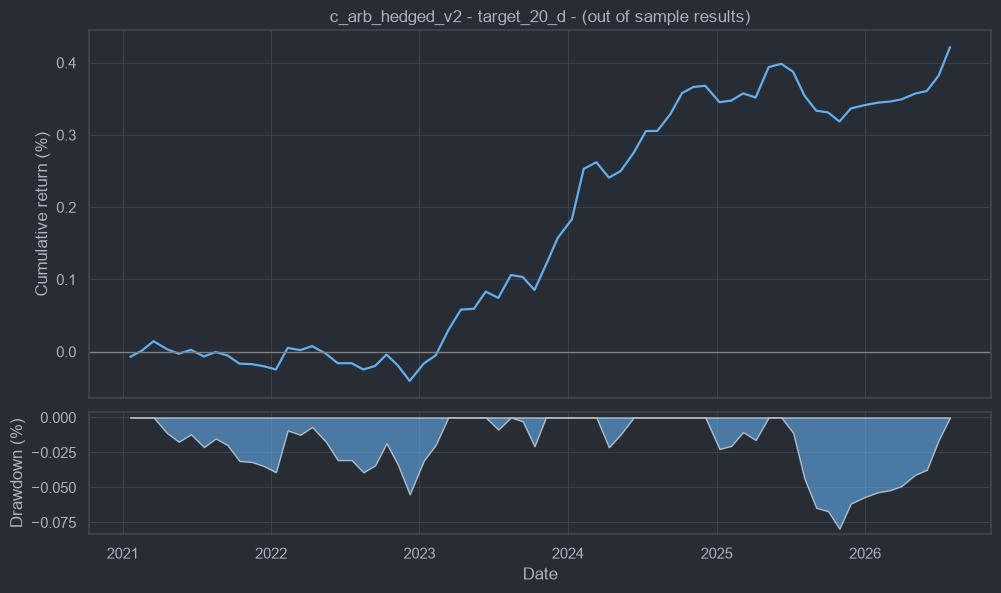

pooled OOS rank IC: 0.1763


In [166]:
# Equity curve, in percent
sample = oos.iloc[::HORIZON]
pnl = np.sign(sample["pred"]) * sample["fwd_raw"]
trade_returns = model.to_simple_returns(pnl, notional=notional.reindex(sample.index))

equity = utilities.plot_equity_curve(trade_returns, title=f"{PRICE} - {TARGET} - (out of sample results)")

scores = model.score_predictions(oos["pred"], oos["fwd_raw"])
print(f"pooled OOS rank IC: {scores:.4f}")